In [2]:
!pip install pmdarima xgboost statsmodels -q
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 3.6 MB/s eta 0:00:00


In [3]:
# ==========================================
# 1. LOAD DATA (PJM Hourly Energy Consumption - PJME region)
# ==========================================
# Source: https://github.com/panambY/Hourly_Energy_Consumption/blob/master/data/PJME_hourly.csv
# (mirrors the Kaggle dataset: https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption)

csv_path = "/content/PJME_hourly.csv"
print("Loading CSV...")
df = pd.read_csv(csv_path)

# Parse datetime and set index
df["Datetime"] = pd.to_datetime(df["Datetime"])

# The raw file has a handful of duplicate timestamps (DST clock-change hours) - keep the first
df = df.drop_duplicates(subset="Datetime").sort_values("Datetime").set_index("Datetime")

# PJME_MW is the average load (MW) for each hourly interval, so summing 24 hourly
# readings for a day already gives the total daily energy in MWh (MW x 1h = MWh)
daily_mwh = df["PJME_MW"].resample("D").sum()

# Filter for three full, most-recent, complete years (mirrors the original 3-year window)
daily = daily_mwh.loc["2015":"2017"].dropna()
daily.name = "Load_MWh"

print(f"Data shape after cleaning: {daily.shape}")
daily.head()


Loading CSV...
Data shape after cleaning: (1096,)


,Load_MWh
Datetime,
2015-01-01,762374.0
2015-01-02,771388.0
2015-01-03,768345.0
2015-01-04,685015.0
2015-01-05,796227.0


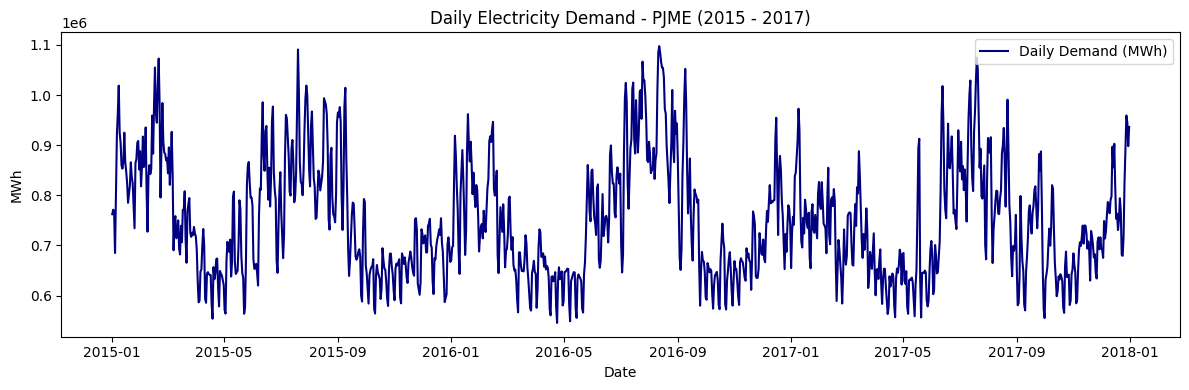

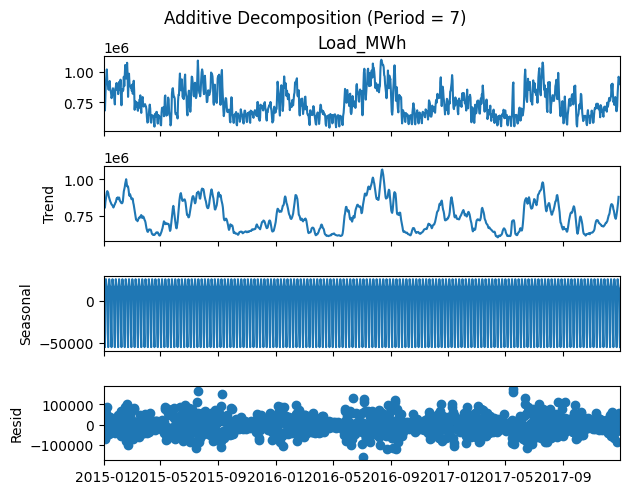

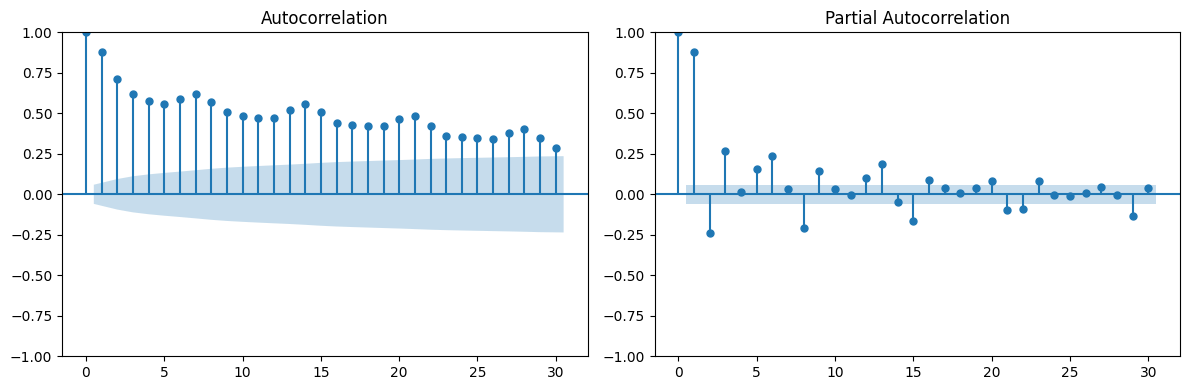


--- Stationarity Test Results ---
ADF Statistic: -3.1672, p-value: 0.0220
KPSS Statistic: 0.1891, p-value: 0.1000


/tmp/ipykernel_869/932028213.py:29: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(daily, regression="c", nlags="auto")


In [4]:
# ==========================================
# 2. EDA & DECOMPOSITION
# ==========================================
# Plot full series
plt.figure(figsize=(12, 4))
plt.plot(daily, color="navy", label="Daily Demand (MWh)")
plt.title("Daily Electricity Demand - PJME (2015 - 2017)")
plt.xlabel("Date")
plt.ylabel("MWh")
plt.legend()
plt.tight_layout()
plt.show()

# Seasonal decomposition (weekly cycle = 7 days)
decomp = seasonal_decompose(daily, model="additive", period=7)
decomp.plot()
plt.suptitle("Additive Decomposition (Period = 7)", y=1.02)
plt.show()

# ACF & PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(daily, lags=30, ax=axes[0], title="Autocorrelation")
plot_pacf(daily, lags=30, ax=axes[1], title="Partial Autocorrelation")
plt.tight_layout()
plt.show()

# Stationarity Tests
adf_res = adfuller(daily)
kpss_res = kpss(daily, regression="c", nlags="auto")

print("\n--- Stationarity Test Results ---")
print(f"ADF Statistic: {adf_res[0]:.4f}, p-value: {adf_res[1]:.4f}")
print(f"KPSS Statistic: {kpss_res[0]:.4f}, p-value: {kpss_res[1]:.4f}")


In [5]:
# ==========================================
# 3. TRAIN / TEST SPLIT
# ==========================================
horizon = 30
train = daily.iloc[:-horizon]
test = daily.iloc[-horizon:]

print(f"\nTrain size: {len(train)} days | Test size: {len(test)} days")



Train size: 1066 days | Test size: 30 days


In [6]:
# ==========================================
# 4. MODEL TRAINING
# ==========================================

# --- Baseline: Seasonal Naive (Repeat last week) ---
s_naive_pred = pd.Series(
    np.tile(train.iloc[-7:].values, int(np.ceil(horizon / 7)))[:horizon],
    index=test.index
)

# --- Model 1: Standard ARIMA ---
print("\nFitting Non-Seasonal ARIMA...")
arima_model = auto_arima(train, seasonal=False, suppress_warnings=True)
arima_pred = pd.Series(arima_model.predict(n_periods=horizon), index=test.index)

# --- Model 2: SARIMA ---
print("Fitting SARIMA (m=7)...")
sarima_model = auto_arima(train, seasonal=True, m=7, suppress_warnings=True)
sarima_pred = pd.Series(sarima_model.predict(n_periods=horizon), index=test.index)

# --- Model 3: XGBoost with Lag Features ---
print("Fitting XGBoost...")
df_xgb = pd.DataFrame({"y": daily})

# Feature engineering
df_xgb["dow"] = df_xgb.index.dayofweek
df_xgb["month"] = df_xgb.index.month
df_xgb["lag1"] = df_xgb["y"].shift(1)
df_xgb["lag7"] = df_xgb["y"].shift(7)
df_xgb["lag14"] = df_xgb["y"].shift(14)
df_xgb["roll7"] = df_xgb["y"].shift(1).rolling(7).mean()

df_xgb = df_xgb.dropna()

features = ["dow", "month", "lag1", "lag7", "lag14", "roll7"]
X = df_xgb[features]
y = df_xgb["y"]

# Train mask (only up to train set split)
train_mask = X.index < test.index[0]
X_train, y_train = X[train_mask], y[train_mask]

xgb = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.03, random_state=42)
xgb.fit(X_train, y_train)

# Multi-step rolling prediction loop
hist = list(train.values)
xgb_predictions = []

for step_date in test.index:
    curr_dow = step_date.dayofweek
    curr_month = step_date.month

    # Take lags from rolling history
    l1 = hist[-1]
    l7 = hist[-7]
    l14 = hist[-14]
    r7 = np.mean(hist[-7:])

    feat_vector = pd.DataFrame([[curr_dow, curr_month, l1, l7, l14, r7]], columns=features)
    pred_val = xgb.predict(feat_vector)[0]

    xgb_predictions.append(pred_val)
    hist.append(pred_val)  # append forecast to history for next step

xgb_pred = pd.Series(xgb_predictions, index=test.index)



Fitting Non-Seasonal ARIMA...
Fitting SARIMA (m=7)...


/usr/local/lib/python3.13/dist-packages/pmdarima/arima/_auto_solvers.py:524: ModelFitWarning: Error fitting  ARIMA(2,0,2)(2,0,0)[7] intercept (if you do not want to see these warnings, run with error_action="ignore").
Traceback:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/pmdarima/arima/_auto_solvers.py", line 508, in _fit_candidate_model
    fit.fit(y, X=X, **fit_params)
    ~~~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/pmdarima/arima/arima.py", line 610, in fit
    self._fit(y, X, **fit_args)
    ~~~~~~~~~^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/pmdarima/arima/arima.py", line 531, in _fit
    fit, self.arima_res_ = _fit_wrapper()
                           ~~~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/pmdarima/arima/arima.py", line 517, in _fit_wrapper
    fitted = arima.fit(
        start_params=start_params,
    ...<3 lines>...
        **fit_args,
    )
  File "/usr/loc

Fitting XGBoost...



--- Final Model Comparison ---
            Model        MAE       RMSE  MAPE (%)
0           ARIMA   85117.68  108558.83     10.04
1          SARIMA   89510.49  115711.81     10.52
2  Seasonal Naive  109867.43  136883.25     13.06
3         XGBoost  114851.83  142211.86     13.66


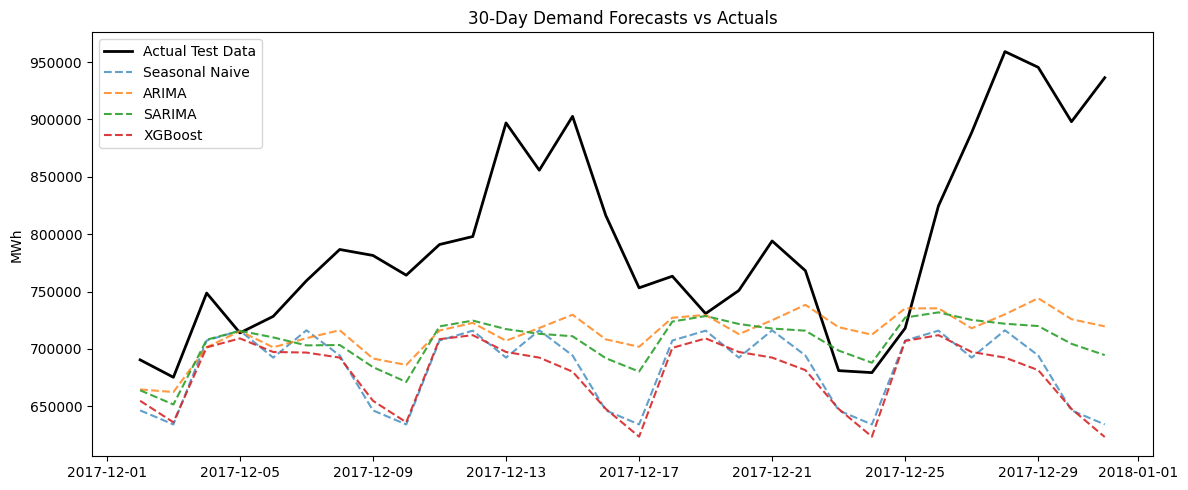

In [7]:
# ==========================================
# 5. EVALUATION
# ==========================================
def get_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mae, rmse, mape

all_models = {
    "Seasonal Naive": s_naive_pred,
    "ARIMA": arima_pred,
    "SARIMA": sarima_pred,
    "XGBoost": xgb_pred
}

metrics_list = []
for name, preds in all_models.items():
    m_mae, m_rmse, m_mape = get_metrics(test, preds)
    metrics_list.append({
        "Model": name,
        "MAE": round(m_mae, 2),
        "RMSE": round(m_rmse, 2),
        "MAPE (%)": round(m_mape, 2)
    })

eval_df = pd.DataFrame(metrics_list).sort_values("RMSE").reset_index(drop=True)
print("\n--- Final Model Comparison ---")
print(eval_df)

# Plot Forecasts
plt.figure(figsize=(12, 5))
plt.plot(test, label="Actual Test Data", color="black", linewidth=2)
plt.plot(s_naive_pred, "--", label="Seasonal Naive", alpha=0.7)
plt.plot(arima_pred, "--", label="ARIMA", alpha=0.8)
plt.plot(sarima_pred, "--", label="SARIMA", alpha=0.9)
plt.plot(xgb_pred, "--", label="XGBoost", alpha=0.9)
plt.title("30-Day Demand Forecasts vs Actuals")
plt.ylabel("MWh")
plt.legend()
plt.tight_layout()
plt.show()



Detected 8 potential anomaly points.


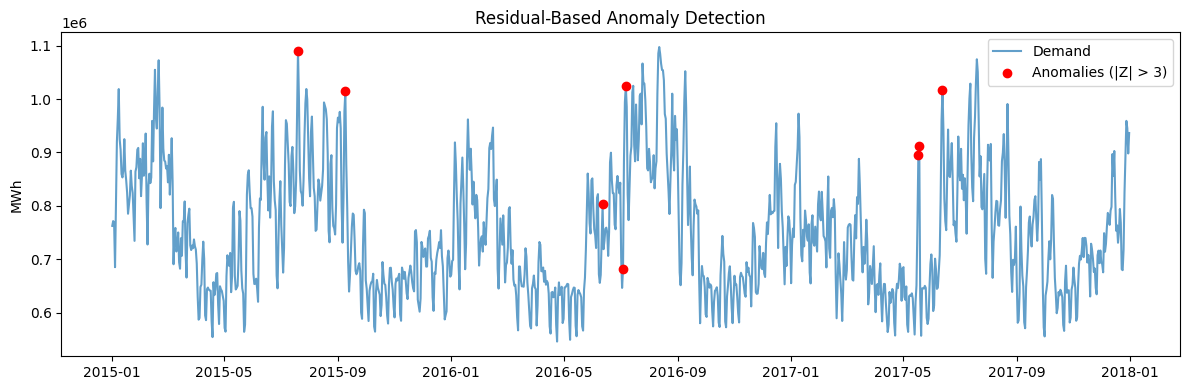

In [8]:
# ==========================================
# 6. ANOMALY DETECTION (Residual Based)
# ==========================================
residuals = decomp.resid.dropna()
z_scores = (residuals - residuals.mean()) / residuals.std()

# Filter by threshold |Z| > 3
anomalies_idx = z_scores.index[z_scores.abs() > 3]
anomalies = daily.loc[anomalies_idx]

print(f"\nDetected {len(anomalies)} potential anomaly points.")

plt.figure(figsize=(12, 4))
plt.plot(daily, label="Demand", color="tab:blue", alpha=0.7)
plt.scatter(anomalies.index, anomalies, color="red", label="Anomalies (|Z| > 3)", zorder=5)
plt.title("Residual-Based Anomaly Detection")
plt.ylabel("MWh")
plt.legend()
plt.tight_layout()
plt.show()
